# M1  Escalabilidad Fuerte y Débil
## Sistema de Recomendación Paralelo para E-Commerce  RetailRocket Dataset
### Entrega 3  Eficiencia y Escalabilidad



- **Escalabilidad fuerte**: mismo dataset completo, variando 1/2/4/8 workers
  (reutiliza la metodología ya validada en la Entrega 2).
- **Escalabilidad débil**: el dataset crece proporcionalmente al número de
  workers (1 worker → N filas, 8 workers → 8N filas), midiendo si el tiempo
  se mantiene constante  que es el comportamiento ideal en este caso.


## 0. Configuración inicial

In [1]:
# !pip install polars dask[dataframe] pandas psutil


In [2]:
import sys
from pathlib import Path

RAIZ_PROYECTO = Path(r"E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Codigos")
sys.path.append(str(RAIZ_PROYECTO / "src"))

from benchmarks import (
    benchmark_etl_workers,             # Escalabilidad fuerte (ya validada en E2)
    benchmark_etl_escalabilidad_debil, # Escalabilidad débil (nueva, E3)
    guardar_resultados,
)

CARPETA_DATASETS = RAIZ_PROYECTO.parent / "Datasets"
CARPETA_RESULTADOS_E3 = RAIZ_PROYECTO / "resultados" / "entrega3"
CARPETA_TEMPORAL = RAIZ_PROYECTO / "datos" / "_tmp_escalabilidad"
CARPETA_RESULTADOS_E3.mkdir(parents=True, exist_ok=True)

ruta_eventos = CARPETA_DATASETS / "events.csv"
print(f"events.csv encontrado: {ruta_eventos.exists()}")


events.csv encontrado: True


## 1. Escalabilidad fuerte

Mismo dataset completo (2.75M filas), variando el número de workers. Esta
metodología ya se validó en la Entrega 2 (`speedup_etl.csv`); se vuelve a
correr aquí para que quede como parte formal del entregable de escalabilidad
de Entrega 3, con el mismo protocolo de warm-up + repeticiones.


In [3]:
resultado_fuerte = benchmark_etl_workers(
    ruta_eventos, lista_workers=[1, 2, 4, 8], n_repeticiones=3, warm_up=1
)
guardar_resultados(resultado_fuerte, "escalabilidad_fuerte.csv", CARPETA_RESULTADOS_E3)
resultado_fuerte


2026-08-01 10:50:40,812 [INFO] blocksize=16MB -> 5 particiones reales generadas
2026-08-01 10:50:40,819 [INFO] Midiendo 'ETL Dask (1 workers, 5 particiones)': 1 warm-up + 3 repeticiones
2026-08-01 10:50:59,044 [INFO]   Repetición 1/3: 6.8690 s
2026-08-01 10:51:06,340 [INFO]   Repetición 2/3: 7.2938 s
2026-08-01 10:51:13,253 [INFO]   Repetición 3/3: 6.9103 s
2026-08-01 10:51:13,257 [INFO] Midiendo 'ETL Dask (2 workers, 5 particiones)': 1 warm-up + 3 repeticiones
2026-08-01 10:51:23,202 [INFO]   Repetición 1/3: 4.8467 s
2026-08-01 10:51:28,343 [INFO]   Repetición 2/3: 5.1362 s
2026-08-01 10:51:33,130 [INFO]   Repetición 3/3: 4.7854 s
2026-08-01 10:51:33,132 [INFO] Midiendo 'ETL Dask (4 workers, 5 particiones)': 1 warm-up + 3 repeticiones
2026-08-01 10:51:41,739 [INFO]   Repetición 1/3: 4.2657 s
2026-08-01 10:51:46,021 [INFO]   Repetición 2/3: 4.2789 s
2026-08-01 10:51:50,363 [INFO]   Repetición 3/3: 4.3381 s
2026-08-01 10:51:50,364 [WARNING] Se pidieron 8 workers pero el archivo solo tie

,etiqueta,media_s,std_s,min_s,max_s,n_repeticiones,workers,particiones,speedup,eficiencia
0,"ETL Dask (1 workers, 5 particiones)",7.0244,0.2343,6.8690,7.2938,3,1,5,1.000,1.000
1,"ETL Dask (2 workers, 5 particiones)",4.9228,0.1874,4.7854,5.1362,3,2,5,1.427,0.714
2,"ETL Dask (4 workers, 5 particiones)",4.2942,0.0386,4.2657,4.3381,3,4,5,1.636,0.409
3,"ETL Dask (8 workers, 5 particiones)",2.9291,0.0486,2.8755,2.9703,3,8,5,2.398,0.300


## 2. Escalabilidad débil

El dataset crece proporcionalmente al número de workers: con `filas_base`
filas para 1 worker, se usan `filas_base * workers` filas para cada
configuración. El comportamiento ideal es que el **tiempo se mantenga
constante**  si crece, significa que el overhead de coordinación crece más
rápido que la capacidad de cómputo agregada.


In [4]:
resultado_debil = benchmark_etl_escalabilidad_debil(
    ruta_eventos,
    carpeta_temporal=CARPETA_TEMPORAL,
    filas_base=300_000,
    lista_workers=[1, 2, 4, 8],
    n_repeticiones=3,
    warm_up=1,
)
guardar_resultados(resultado_debil, "escalabilidad_debil.csv", CARPETA_RESULTADOS_E3)
resultado_debil


2026-08-01 10:52:04,582 [INFO] Preparando subconjunto de 300,000 filas para 1 worker(s)
2026-08-01 10:52:04,813 [INFO] Midiendo 'Escalabilidad débil (1 workers, 300,000 filas)': 1 warm-up + 3 repeticiones
2026-08-01 10:52:06,265 [INFO]   Repetición 1/3: 0.7747 s
2026-08-01 10:52:06,985 [INFO]   Repetición 2/3: 0.7187 s
2026-08-01 10:52:07,646 [INFO]   Repetición 3/3: 0.6590 s
2026-08-01 10:52:07,650 [INFO] Preparando subconjunto de 600,000 filas para 2 worker(s)
2026-08-01 10:52:07,918 [INFO] Midiendo 'Escalabilidad débil (2 workers, 600,000 filas)': 1 warm-up + 3 repeticiones
2026-08-01 10:52:10,852 [INFO]   Repetición 1/3: 1.4272 s
2026-08-01 10:52:12,625 [INFO]   Repetición 2/3: 1.7713 s
2026-08-01 10:52:14,137 [INFO]   Repetición 3/3: 1.5088 s
2026-08-01 10:52:14,144 [INFO] Preparando subconjunto de 1,200,000 filas para 4 worker(s)
2026-08-01 10:52:14,708 [INFO] Midiendo 'Escalabilidad débil (4 workers, 1,200,000 filas)': 1 warm-up + 3 repeticiones
2026-08-01 10:52:18,865 [INFO]   

,etiqueta,media_s,std_s,min_s,max_s,n_repeticiones,workers,filas,eficiencia_debil
0,"Escalabilidad débil (1 workers, 300,000 filas)",0.7175,0.0579,0.6590,0.7747,3,1,300000,1.000
1,"Escalabilidad débil (2 workers, 600,000 filas)",1.5691,0.1798,1.4272,1.7713,3,2,600000,0.457
2,"Escalabilidad débil (4 workers, 1,200,000 filas)",2.1144,0.0476,2.0699,2.1645,3,4,1200000,0.339
3,"Escalabilidad débil (8 workers, 2,400,000 filas)",2.9842,0.0793,2.8949,3.0467,3,8,2400000,0.240


## 3. Visualización comparativa

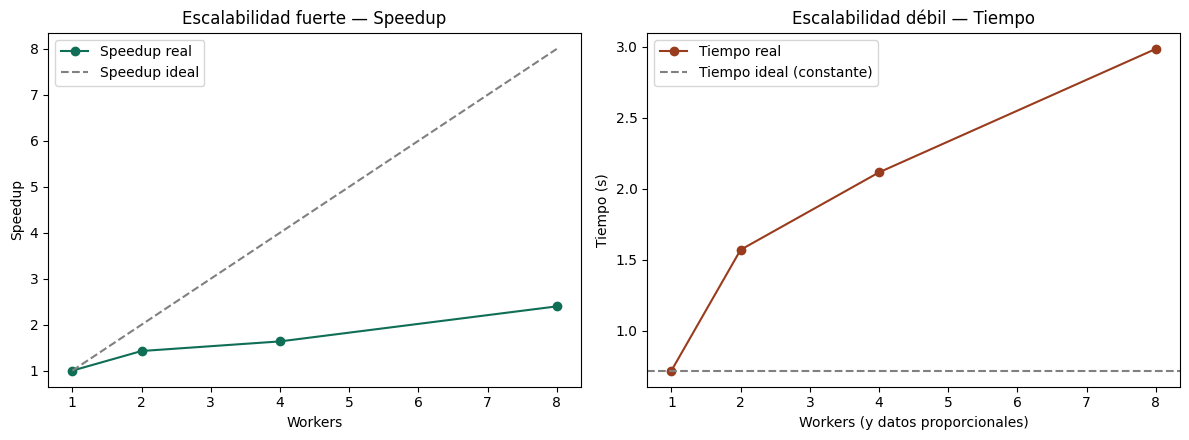

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(resultado_fuerte["workers"], resultado_fuerte["speedup"], marker="o", color="#0F6E56", label="Speedup real")
axes[0].plot(resultado_fuerte["workers"], resultado_fuerte["workers"], linestyle="--", color="gray", label="Speedup ideal")
axes[0].set_title("Escalabilidad fuerte — Speedup"); axes[0].set_xlabel("Workers"); axes[0].set_ylabel("Speedup"); axes[0].legend()

axes[1].plot(resultado_debil["workers"], resultado_debil["media_s"], marker="o", color="#993C1D", label="Tiempo real")
axes[1].axhline(resultado_debil["media_s"].iloc[0], linestyle="--", color="gray", label="Tiempo ideal (constante)")
axes[1].set_title("Escalabilidad débil — Tiempo"); axes[1].set_xlabel("Workers (y datos proporcionales)"); axes[1].set_ylabel("Tiempo (s)"); axes[1].legend()

plt.tight_layout()
plt.savefig(CARPETA_RESULTADOS_E3 / "escalabilidad_fuerte_debil.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Interpretación

**Escalabilidad fuerte:** ver el techo de speedup ya documentado en la
Entrega 2 (Amdahl, fracción secuencial ~54%). Se reafirma aquí sobre el
dataset completo con el protocolo formal de Entrega 3.

**Escalabilidad débil:** si `eficiencia_debil` se mantiene cercana a 1.0 en
todas las configuraciones, el sistema escala bien ante crecimiento de datos
proporcional a los recursos  un requisito más realista para el escenario de
"pico de tráfico tipo Black Friday" que exige el proyecto, donde tanto los
datos como (potencialmente) los recursos de cómputo crecen juntos.

